# Лабораторная работа 5

## Ансамбли моделей машинного обучения. Часть 1.
### Цель лабораторной работы: изучение ансамблей моделей машинного обучения.

# Датасет:
Текстовое описание набора данных
Набор данных по исследованию качества воздуха - https://archive.ics.uci.edu/dataset/360/air+quality

Набор содержит почасовые данные, полученные от комбинированного газоанализатора, установленного в итальянском городе вблизи автомобильной магистрали. Данные записывались с Марта 2004 по февраль 2005 (один год).

Датасет состоит из 2-х файлов одинаковых данных в формате .csv и .xlsx

Каждый файл содержит следующие колонки:

Date дата в формате ДЕНЬ-МЕСЯЦ-ГОД Набор данных содержит данные с интервалом измерения в один час.
Time время в формате ЧАСЫ:МИНУТЫ:СЕКУНДЫ.
CO(GT) концентрация СО mg/m^3
PT08.S1(CO) концентрация СО mg/m^3 усредненная за час
NMHC(GT) максимальная концентрация паров гидрокарбонатов усредненная за час microg/m^3
C6H6(GT) максимальная концентрация паров бензина усредненная за час microg/m^3
PT08.S2(NMHC) концентрация паров гидрокарбонатов усредненная за час microg/m^3
NOx(GT) максимальная концентрация оксидов азота усредненная за час microg/m^3
PT08.S3(NOx) концентрация оксидов азота усредненная за час microg/m^3
NO2(GT) максимальная концентрация двуокиси азота усредненная за час microg/m^3
PT08.S4(NO2) концентрация двуокиси азота усредненная за час microg/m^3
PT08.S5(O3) концентрация озона усредненная за час microg/m^3
T температура в градусах Цельсия
RH относительная влажность в %.
AH абсолютная влажность в %.
Category категория качества воздуха - Good/Bad


In [12]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from IPython.display import Image
from io import StringIO 
from IPython.display import Image
import graphviz 
import pydotplus
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [13]:
# 
data = pd.read_csv('air+quality/2.csv', sep=";")
data = data.drop(columns=['Unnamed: 16'])

In [14]:
# Первые 5 строк датасета
data.head()

,Date,Time,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH,Category
0,10.03.2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268,13.6,48.9,0.7578,Bad
1,10.03.2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972,13.3,47.7,0.7255,Bad
2,10.03.2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074,11.9,54.0,0.7502,Bad
3,10.03.2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203,11.0,60.0,0.7867,Bad
4,10.03.2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110,11.2,59.6,0.7888,Good


In [15]:
#Удаление строк с пропусками
data = data.dropna(axis=0, how='any')
data.shape

(827, 16)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 0 to 1230
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        827 non-null    object 
 1   Time        827 non-null    object 
 2   COGT        827 non-null    float64
 3   PT08S1CO    827 non-null    float64
 4   NMHCGT      827 non-null    float64
 5   C6H6GT      827 non-null    float64
 6   PT08S2NMHC  827 non-null    float64
 7   NOxGT       827 non-null    float64
 8   PT08S3NOx   827 non-null    float64
 9   NO2GT       827 non-null    float64
 10  PT08S4NO2   827 non-null    float64
 11  PT08S5O3    827 non-null    int64  
 12  T           827 non-null    float64
 13  RH          827 non-null    float64
 14  AH          827 non-null    float64
 15  Category    827 non-null    object 
dtypes: float64(12), int64(1), object(3)
memory usage: 109.8+ KB


In [17]:
data.describe()

,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000
mean,2.353567,1207.879081,231.025393,10.771100,966.116082,143.501814,963.297461,100.259976,1600.620314,1045.812576,15.601451,49.050181,0.831853
std,1.409496,241.816997,208.461912,7.418134,266.424557,81.829717,265.914168,31.493823,302.291793,400.134662,4.825304,15.266746,0.178506
min,0.300000,753.000000,7.000000,0.500000,448.000000,12.000000,461.000000,19.000000,955.000000,263.000000,6.300000,14.900000,0.402300
25%,1.300000,1017.000000,77.000000,4.800000,754.000000,81.000000,769.000000,78.500000,1369.500000,760.000000,11.900000,36.700000,0.718950
50%,2.000000,1172.000000,157.000000,9.100000,944.000000,128.000000,920.000000,99.000000,1556.000000,1009.000000,15.000000,49.600000,0.817700
75%,3.100000,1380.000000,318.500000,14.800000,1142.500000,187.000000,1131.000000,122.000000,1783.500000,1320.000000,18.300000,60.550000,0.927500
max,8.100000,2040.000000,1189.000000,39.200000,1754.000000,478.000000,1935.000000,196.000000,2679.000000,2359.000000,30.000000,83.200000,1.485200


In [94]:
def make_meshgrid(x, y, h=.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    #Можно проверить все ли метки классов предсказываются
    #print(np.unique(Z))
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_cl(clf):
    title = clf.__repr__
    Xc = X[['COGT','C6H6GT']]
    clf.fit(Xc.to_numpy(), y)
    fig, ax = plt.subplots(figsize=(5,5))
    X0, X1 = X['COGT'], X['C6H6GT']
    xx, yy = make_meshgrid(X0, X1)
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('CO')
    ax.set_ylabel('C6H6')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
    plt.show()


In [95]:
from operator import itemgetter

def draw_feature_importances(tree_model, X_dataset, figsize=(10,5)):
    """
    Вывод важности признаков в виде графика
    """
    # Сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    # Названия признаков
    labels = [x for x,_ in sorted_list]
    # Важности признаков
    data = [x for _,x in sorted_list]
    # Вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    # Вывод значений
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data

In [96]:
# Визуализация дерева
def get_png_tree(tree_model_param, feature_names_param):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph.create_png()

In [97]:
def accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса, 
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame 
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют 
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values, 
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [98]:
#Преобразование категориальных признаков в числовые
from sklearn.preprocessing import OrdinalEncoder
data_oe = data[['Category']]
oe = OrdinalEncoder()
enc_oe = oe.fit_transform(data_oe)

# Бэггинг

In [99]:
# Используем 4 признака
X = data[['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']]
y = enc_oe[:, 0]

In [100]:
# Обучим классификатор на 5 деревьях
bc1 = BaggingClassifier(n_estimators=5, oob_score=True, random_state=10)
bc1.fit(X, y)

/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_bagging.py:917: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_bagging.py:923: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


,estimator,None
,n_estimators,5
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,10
,verbose,0


In [101]:
# Какие объекты были использованы в обучающей выборке каждого дерева
bc1.estimators_samples_

[array([421, 649, 433, 436, 138, 766, 794, 202, 238, 394, 447, 691, 562,
        382, 496, 546, 733, 792, 555, 405, 754, 486, 740, 748, 762, 826,
        368, 755, 630, 360, 814, 104, 715, 539, 805, 740, 813, 187, 438,
        388,  44,  69, 412, 747, 746, 279, 423, 620, 188, 427,   0, 767,
         50, 713, 406, 590,  42, 112,  77, 668, 306,   4, 626, 782, 568,
        170, 460, 299,  39, 248, 196, 703, 555, 139, 468, 237, 592, 432,
        639, 415, 372, 225,  56,  54, 711, 210, 622, 394, 237, 220, 648,
        461, 772,  79, 812, 572, 730, 111, 330, 153, 626, 381, 451, 393,
        709, 614, 153, 344,  14, 642, 619, 175, 374, 809, 731, 407, 574,
        464,  37,  14,  52, 632, 224, 171, 465, 324, 688, 683, 472, 725,
        329, 190, 551, 242, 444, 616,  92, 454, 662, 504, 556, 139, 421,
        534, 767, 423, 578, 675, 427, 283, 241, 480, 750, 341, 310,  40,
        478, 492, 490, 607, 806,  92, 502, 698, 714, 759, 317, 731, 372,
        585, 699, 628, 560,  20, 124, 549, 826, 357

In [102]:
# Сконвертируем эти данные в двоичную матрицу, 
# 1 соответствует элементам, попавшим в обучающую выборку
bin_array = np.zeros((5, X.shape[0]))
for i in range(5):
    for j in bc1.estimators_samples_[i]:
        bin_array[i][j] = 1
bin_array

array([[1., 0., 0., ..., 0., 1., 1.],
       [0., 1., 1., ..., 1., 1., 1.],
       [1., 1., 0., ..., 1., 0., 1.],
       [1., 0., 1., ..., 1., 1., 0.],
       [0., 1., 1., ..., 1., 1., 0.]], shape=(5, 827))

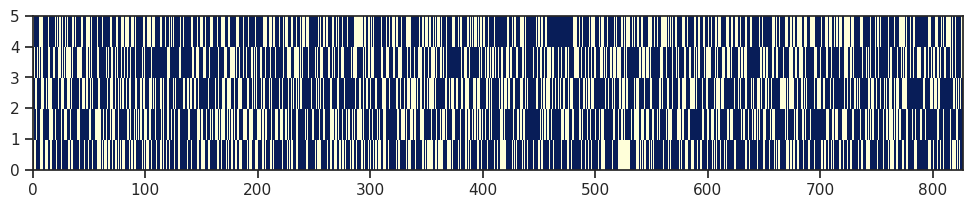

In [103]:
# И визуализируем (синим цветом показаны данные, которые попали в обучающую выборку)
fig, ax = plt.subplots(figsize=(12,2))
ax.pcolor(bin_array, cmap='YlGnBu')
plt.show()

In [104]:
# Оценим Out-of-bag error, теоретическое значение 37%
for i in range(5):
    cur_data = bin_array[i]
    len_cur_data = len(cur_data)
    sum_cur_data = sum(cur_data)
    (len(bin_array[0]) - sum(bin_array[0])) / len(bin_array[0])
    oob_i = (len_cur_data - sum_cur_data) / len_cur_data
    print('Для модели № {} размер OOB составляет {}%'.format(i+1, round(oob_i, 4)*100.0))

Для модели № 1 размер OOB составляет 36.03%
Для модели № 2 размер OOB составляет 36.28%
Для модели № 3 размер OOB составляет 37.0%
Для модели № 4 размер OOB составляет 36.4%
Для модели № 5 размер OOB составляет 39.18%


In [105]:
# Out-of-bag error, возвращаемый классификатором
# Для классификации используется метрика accuracy
bc1.oob_score_, 1-bc1.oob_score_

(0.939540507859734, 0.060459492140266025)

In [106]:
# Параметр oob_decision_function_ возвращает вероятности 
# принадлежности объекта к классам на основе oob
# В данном примере два класса, 
# значения nan могут возвращаться в случае маленькой выборки
bc1.oob_decision_function_[55:70]

array([[nan, nan],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [nan, nan],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 1.,  0.]])

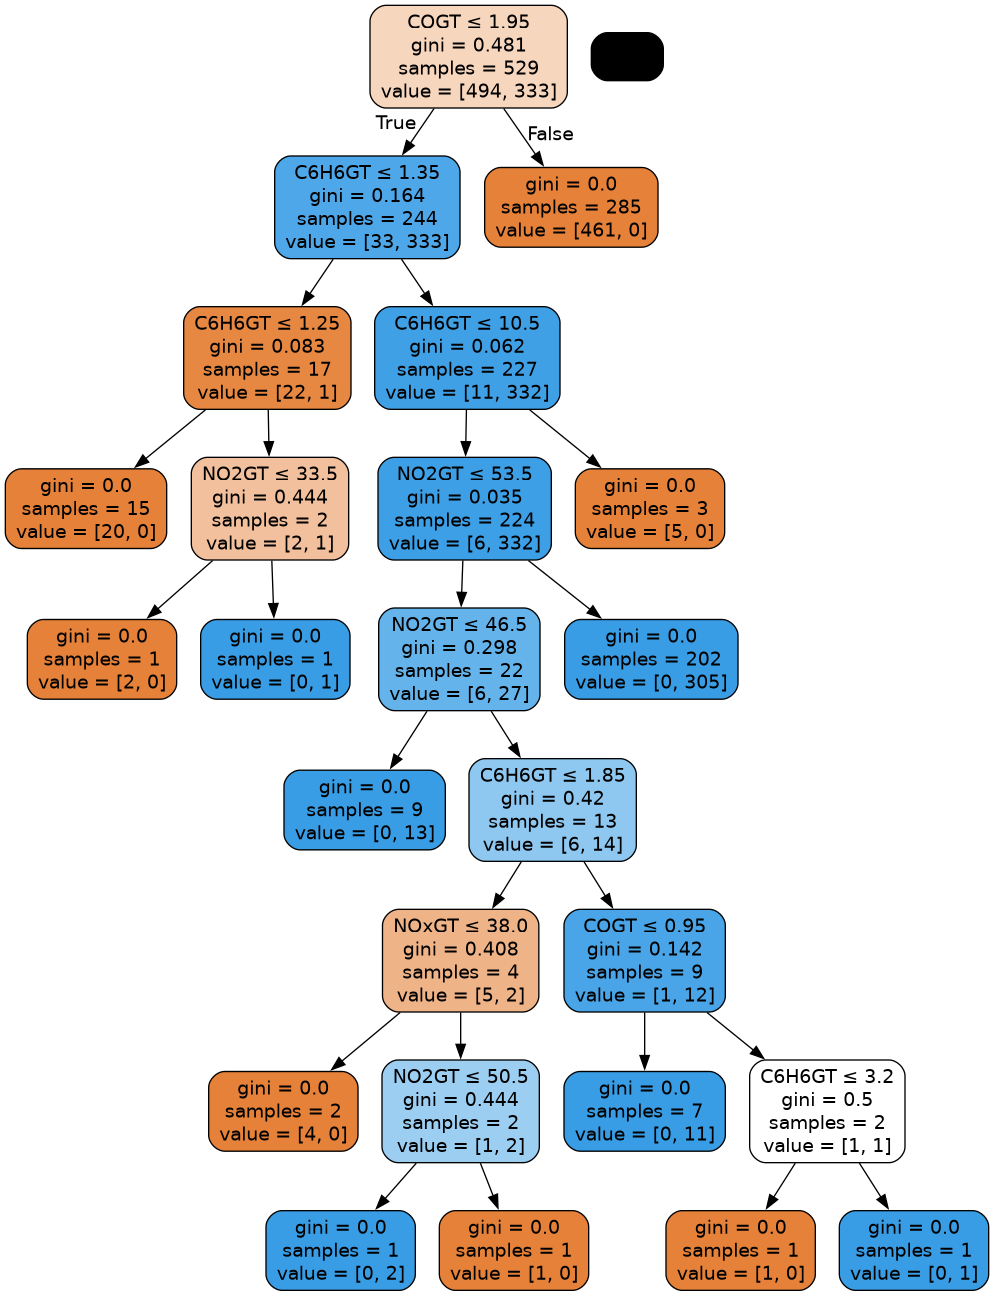

In [107]:
# Визуализация обученных решающих деревьев
Image(get_png_tree(bc1.estimators_[0],['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='80%')

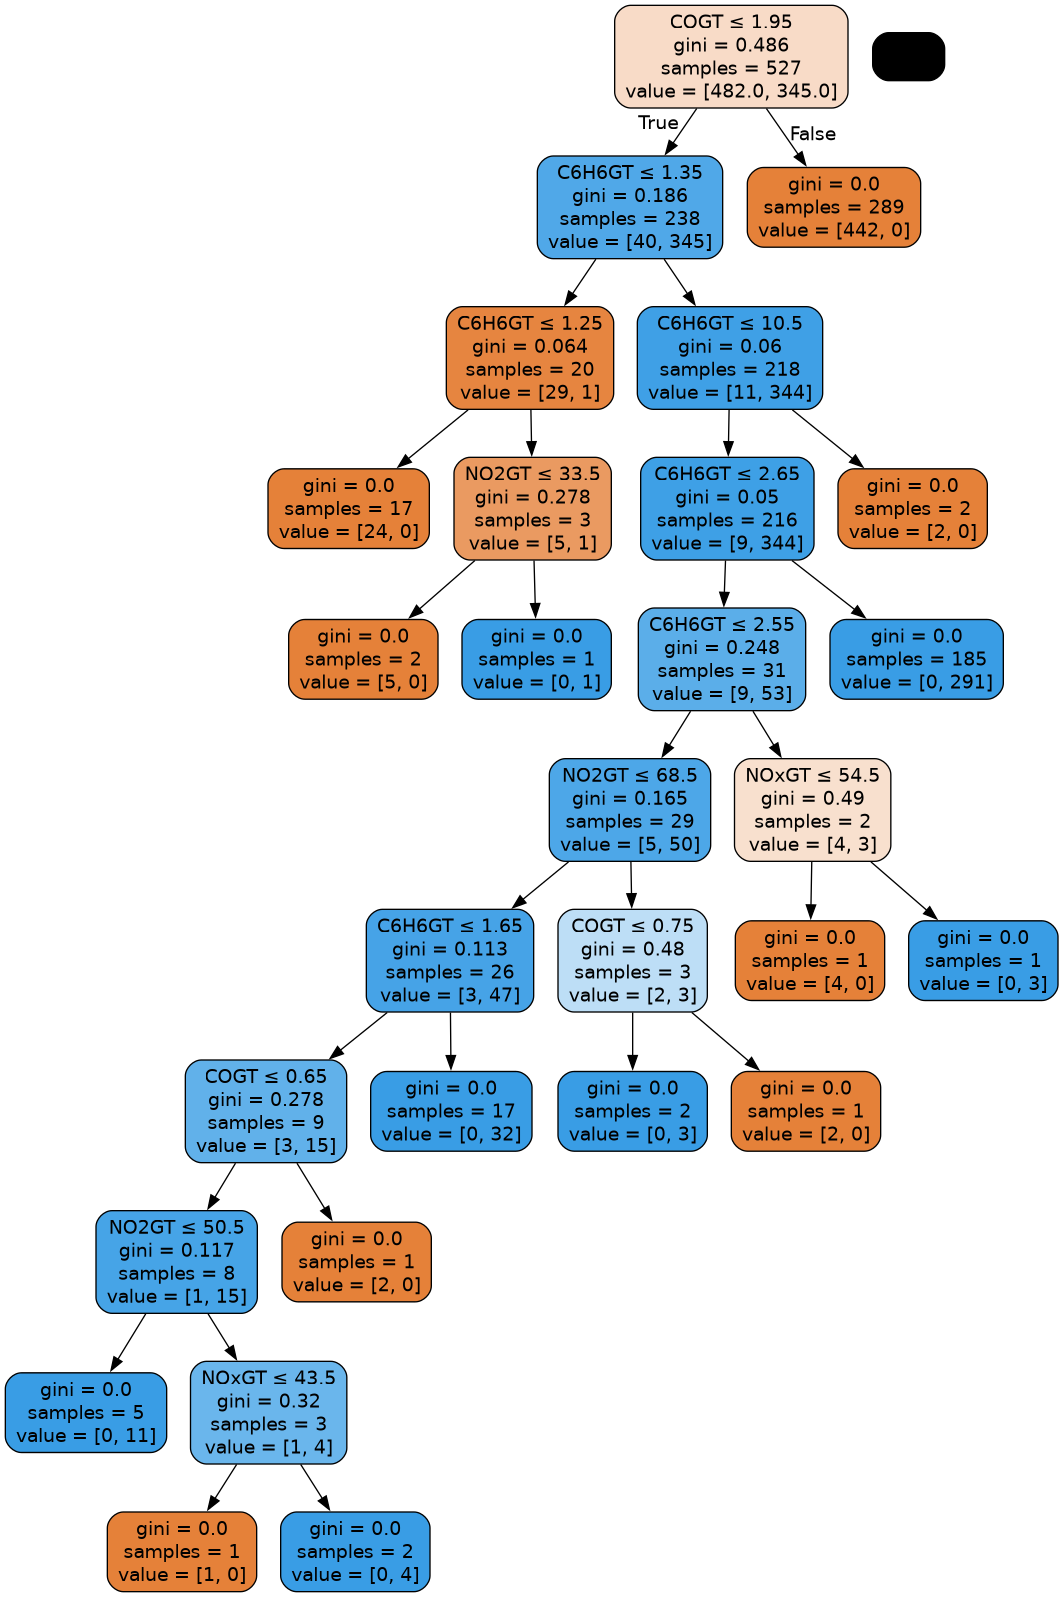

In [108]:
Image(get_png_tree(bc1.estimators_[1],['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='80%')

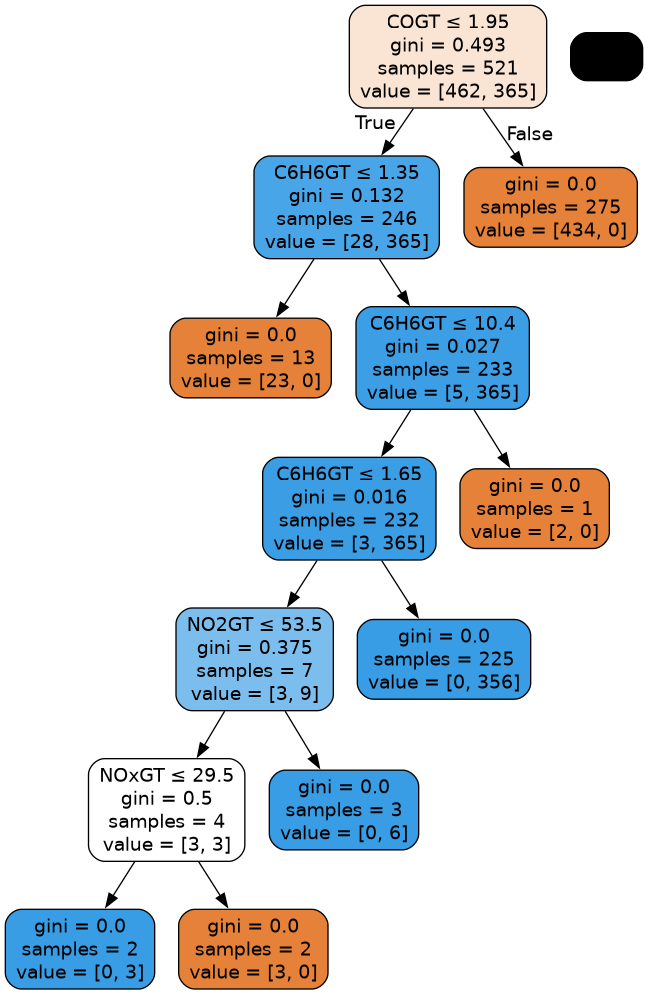

In [109]:
Image(get_png_tree(bc1.estimators_[2],['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='80%')

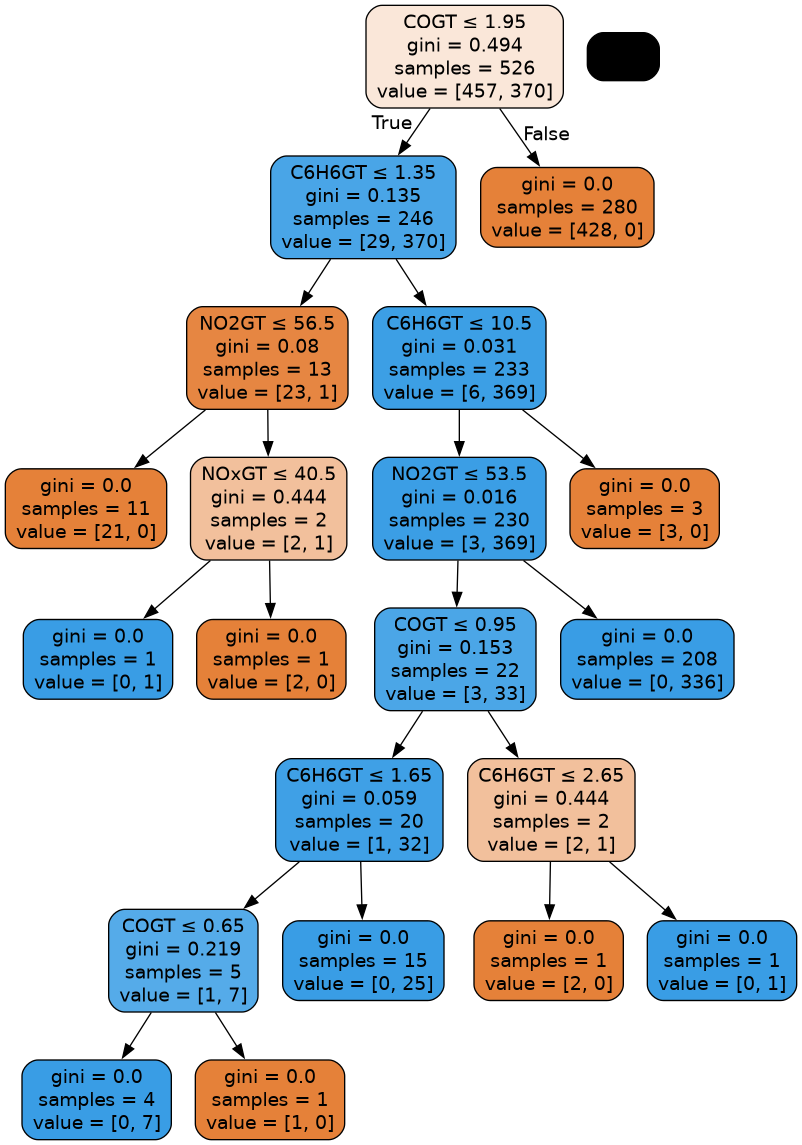

In [110]:
Image(get_png_tree(bc1.estimators_[3],['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='80%')

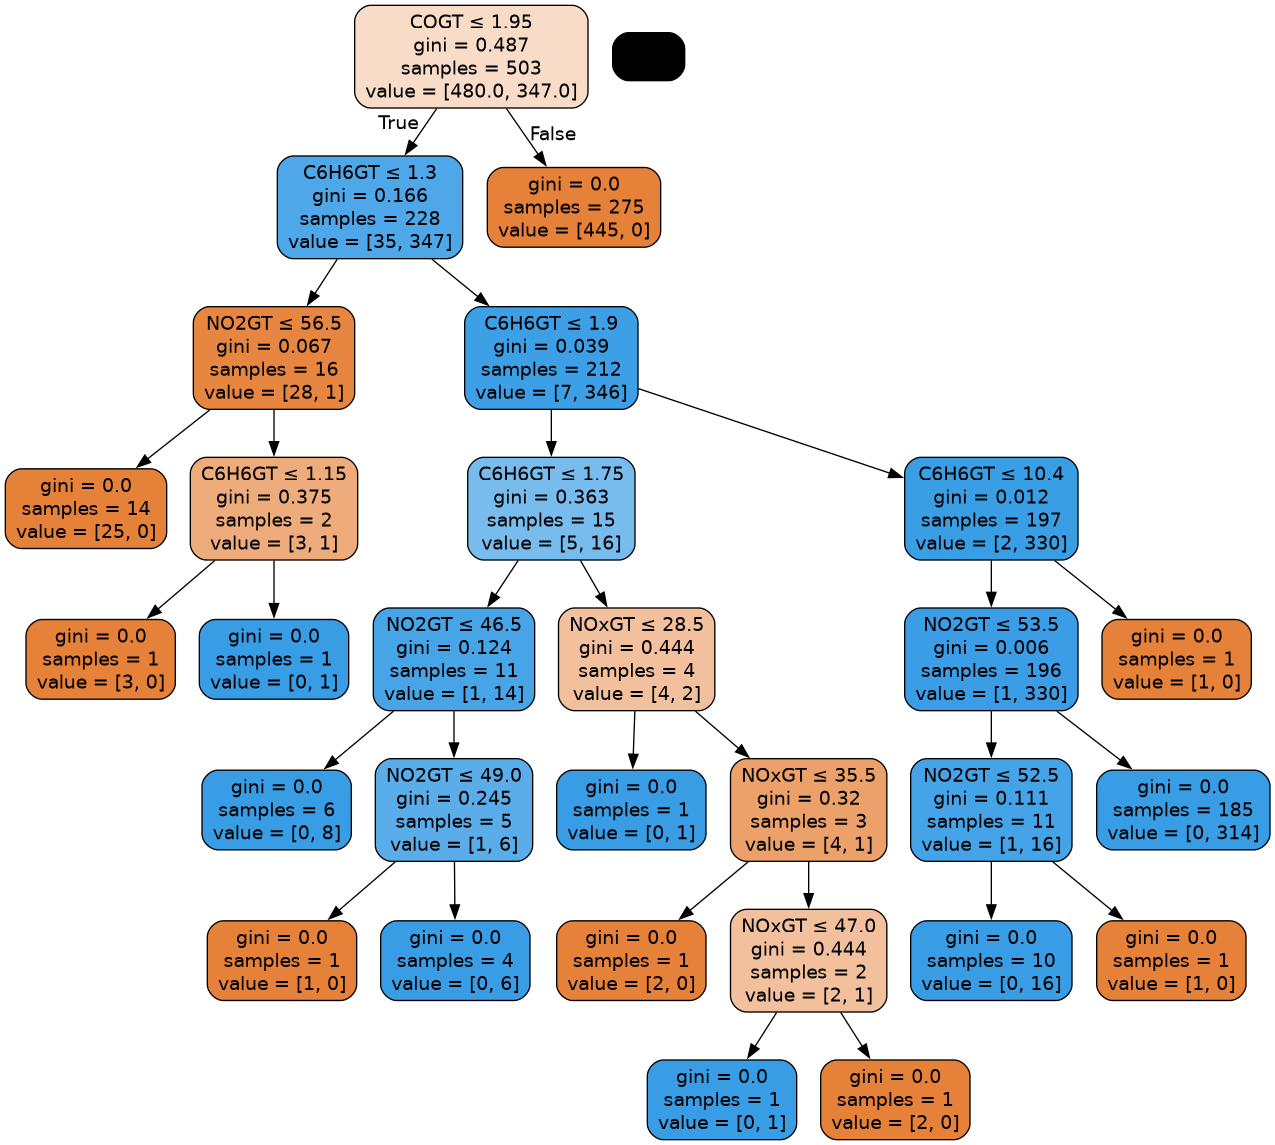

In [111]:
Image(get_png_tree(bc1.estimators_[4],['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='80%')

## Визуализация результатов классификации

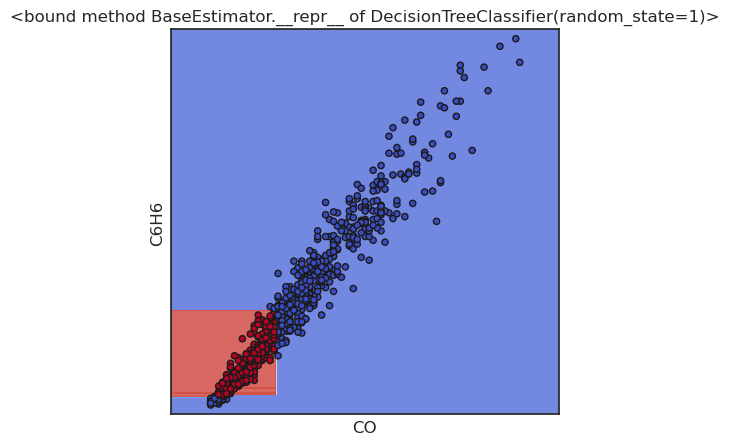

In [112]:
plot_cl(DecisionTreeClassifier(random_state=1))

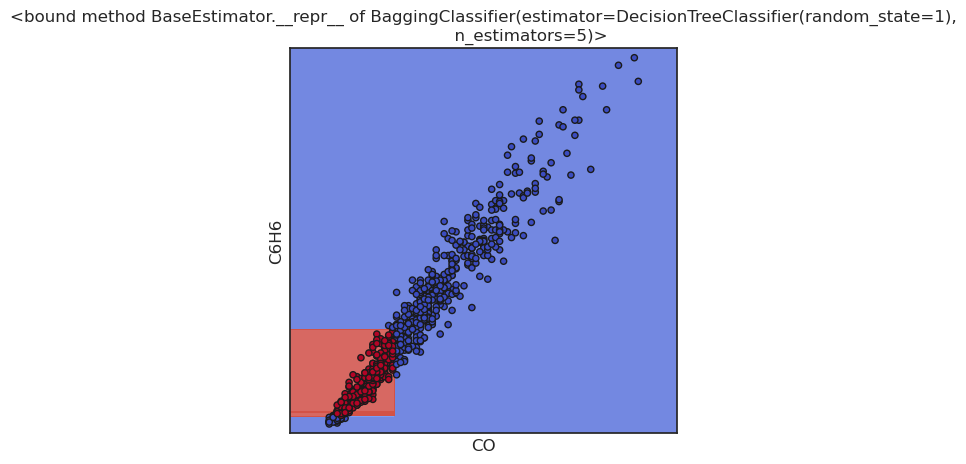

In [113]:
plot_cl(BaggingClassifier(DecisionTreeClassifier(random_state=1), n_estimators=5))

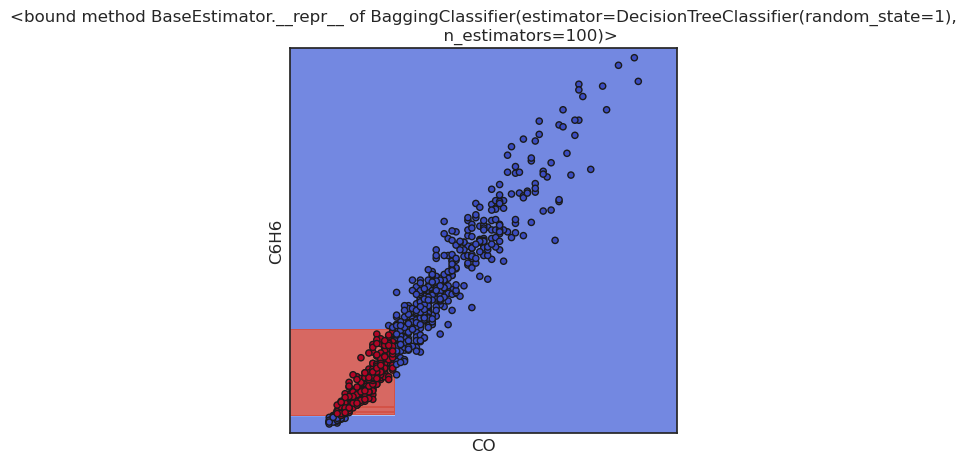

In [114]:
plot_cl(BaggingClassifier(DecisionTreeClassifier(random_state=1), n_estimators=100))

# Случайный лес

In [115]:
# Обучим классификатор на 5 деревьях
tree1 = RandomForestClassifier(n_estimators=5, oob_score=True, random_state=10)
tree1.fit(X, y)

/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [116]:
# Out-of-bag error, возвращаемый классификатором
tree1.oob_score_, 1-tree1.oob_score_

(0.932285368802902, 0.06771463119709797)

In [117]:
tree1.oob_decision_function_[55:70]

array([[0., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

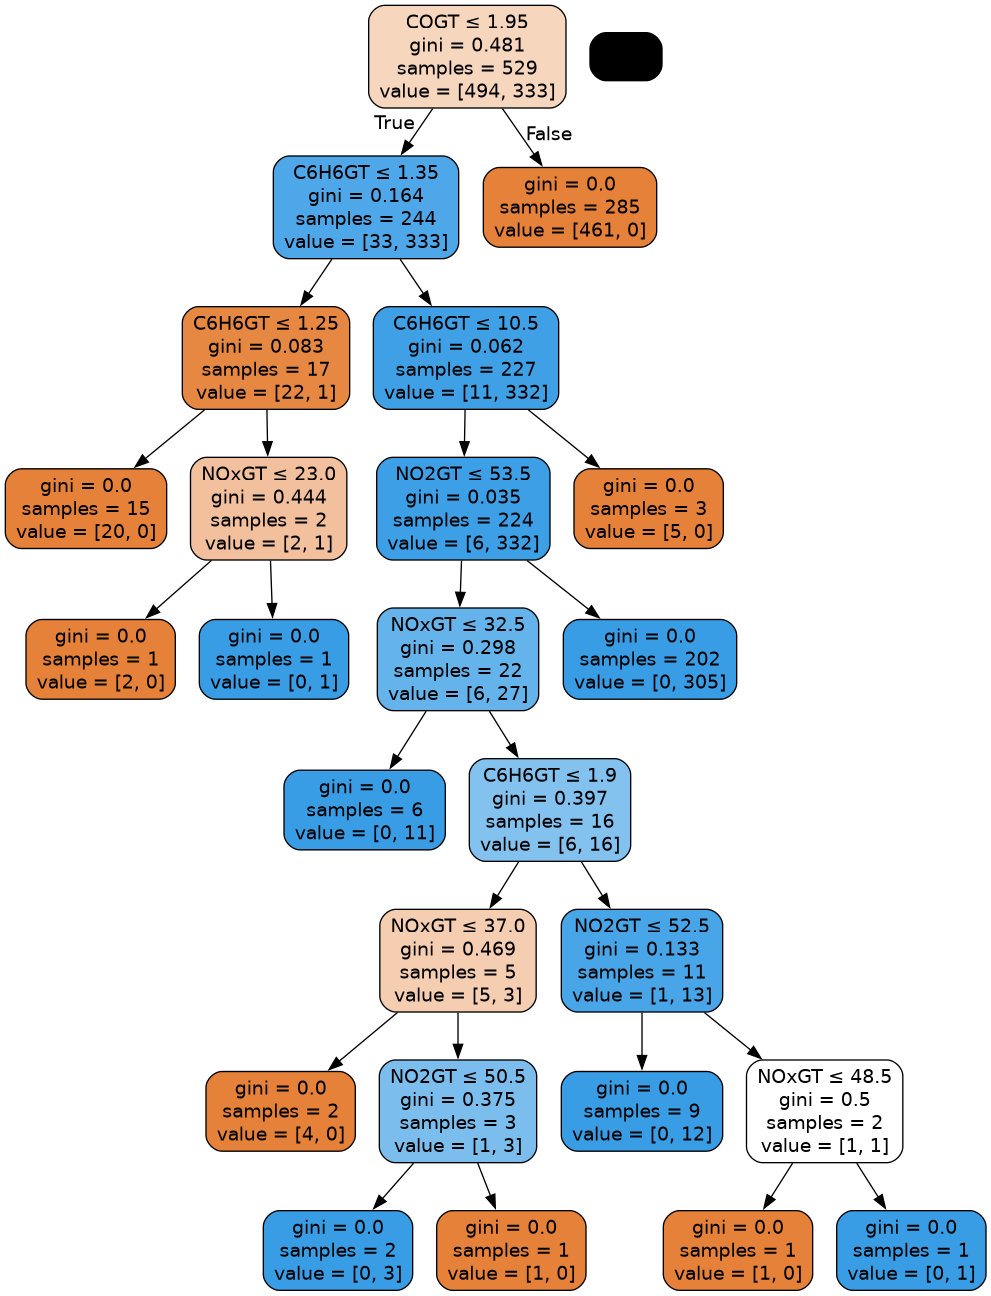

In [119]:
Image(get_png_tree(tree1.estimators_[0], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width="500")

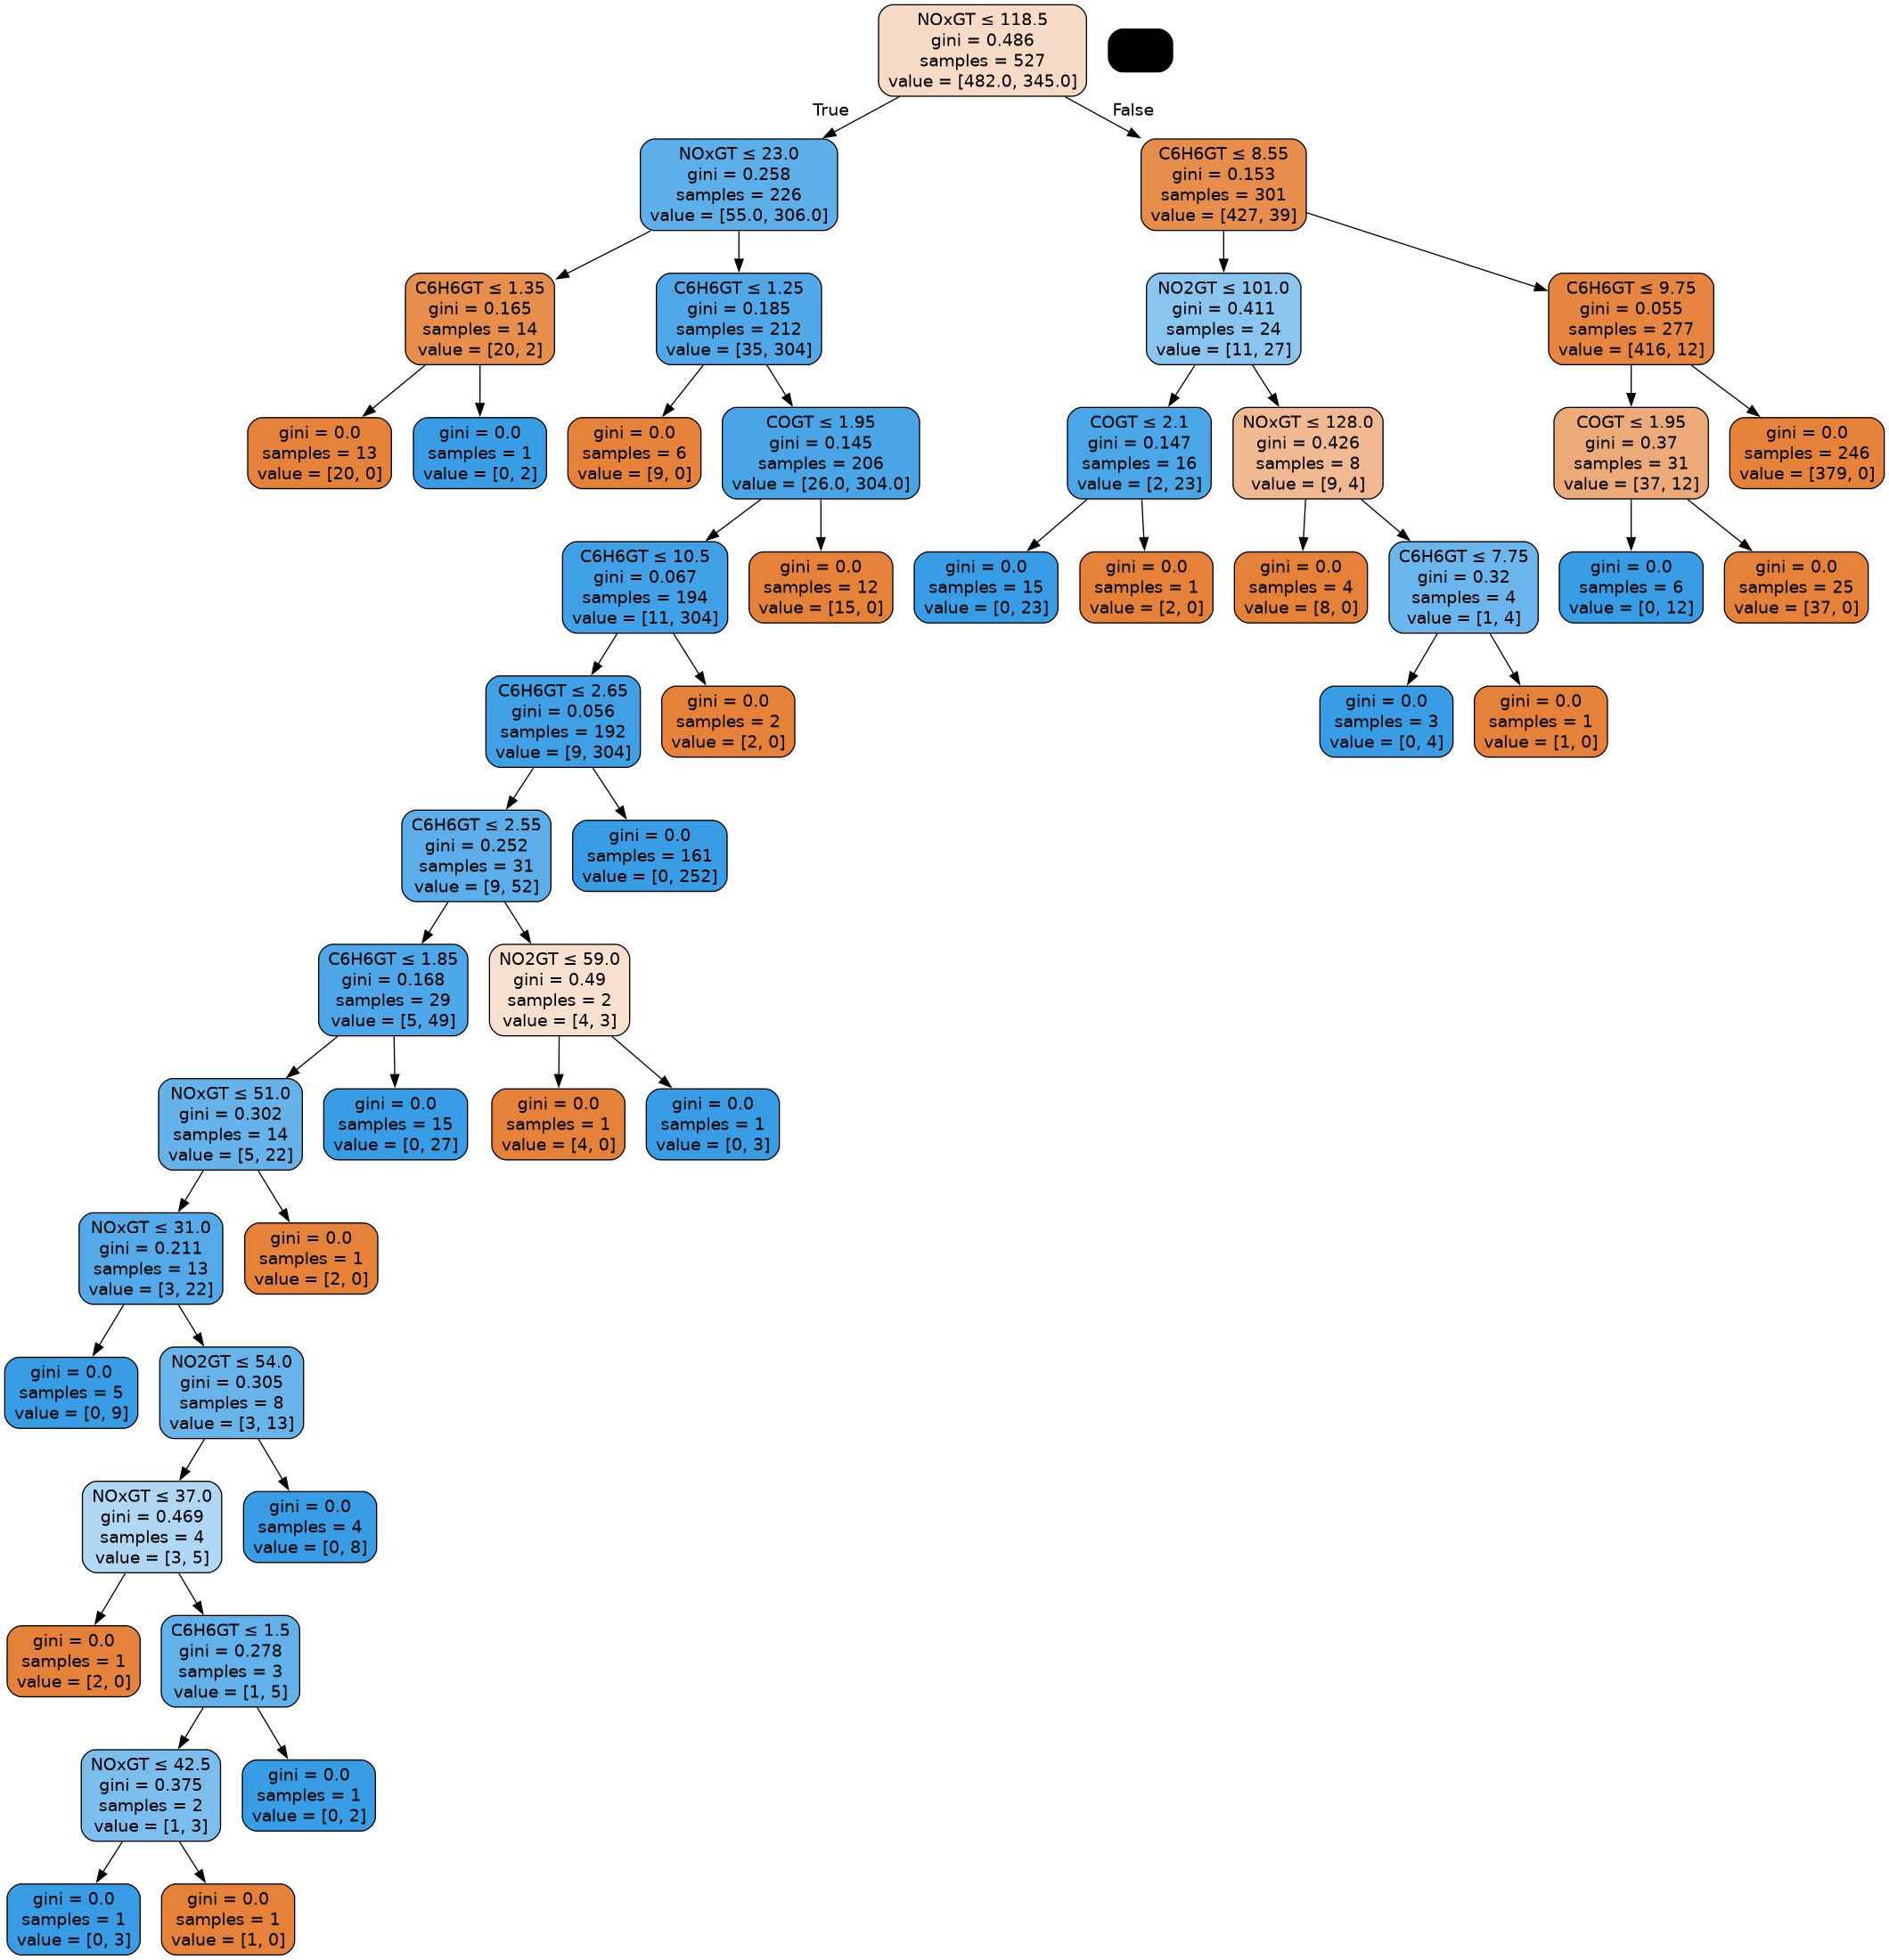

In [120]:
Image(get_png_tree(tree1.estimators_[1], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width="500")

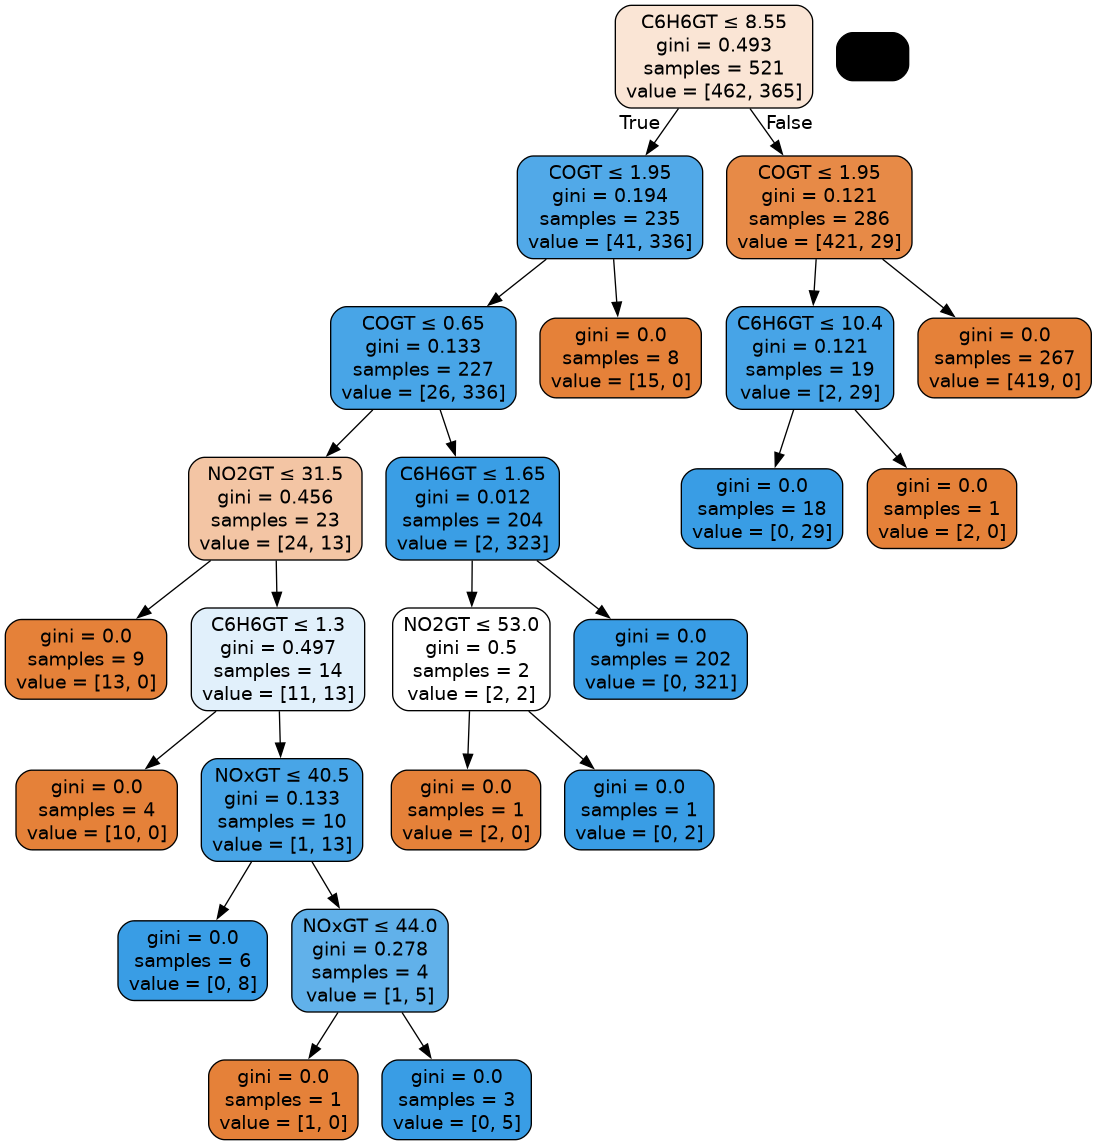

In [121]:
Image(get_png_tree(tree1.estimators_[2], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width="500")

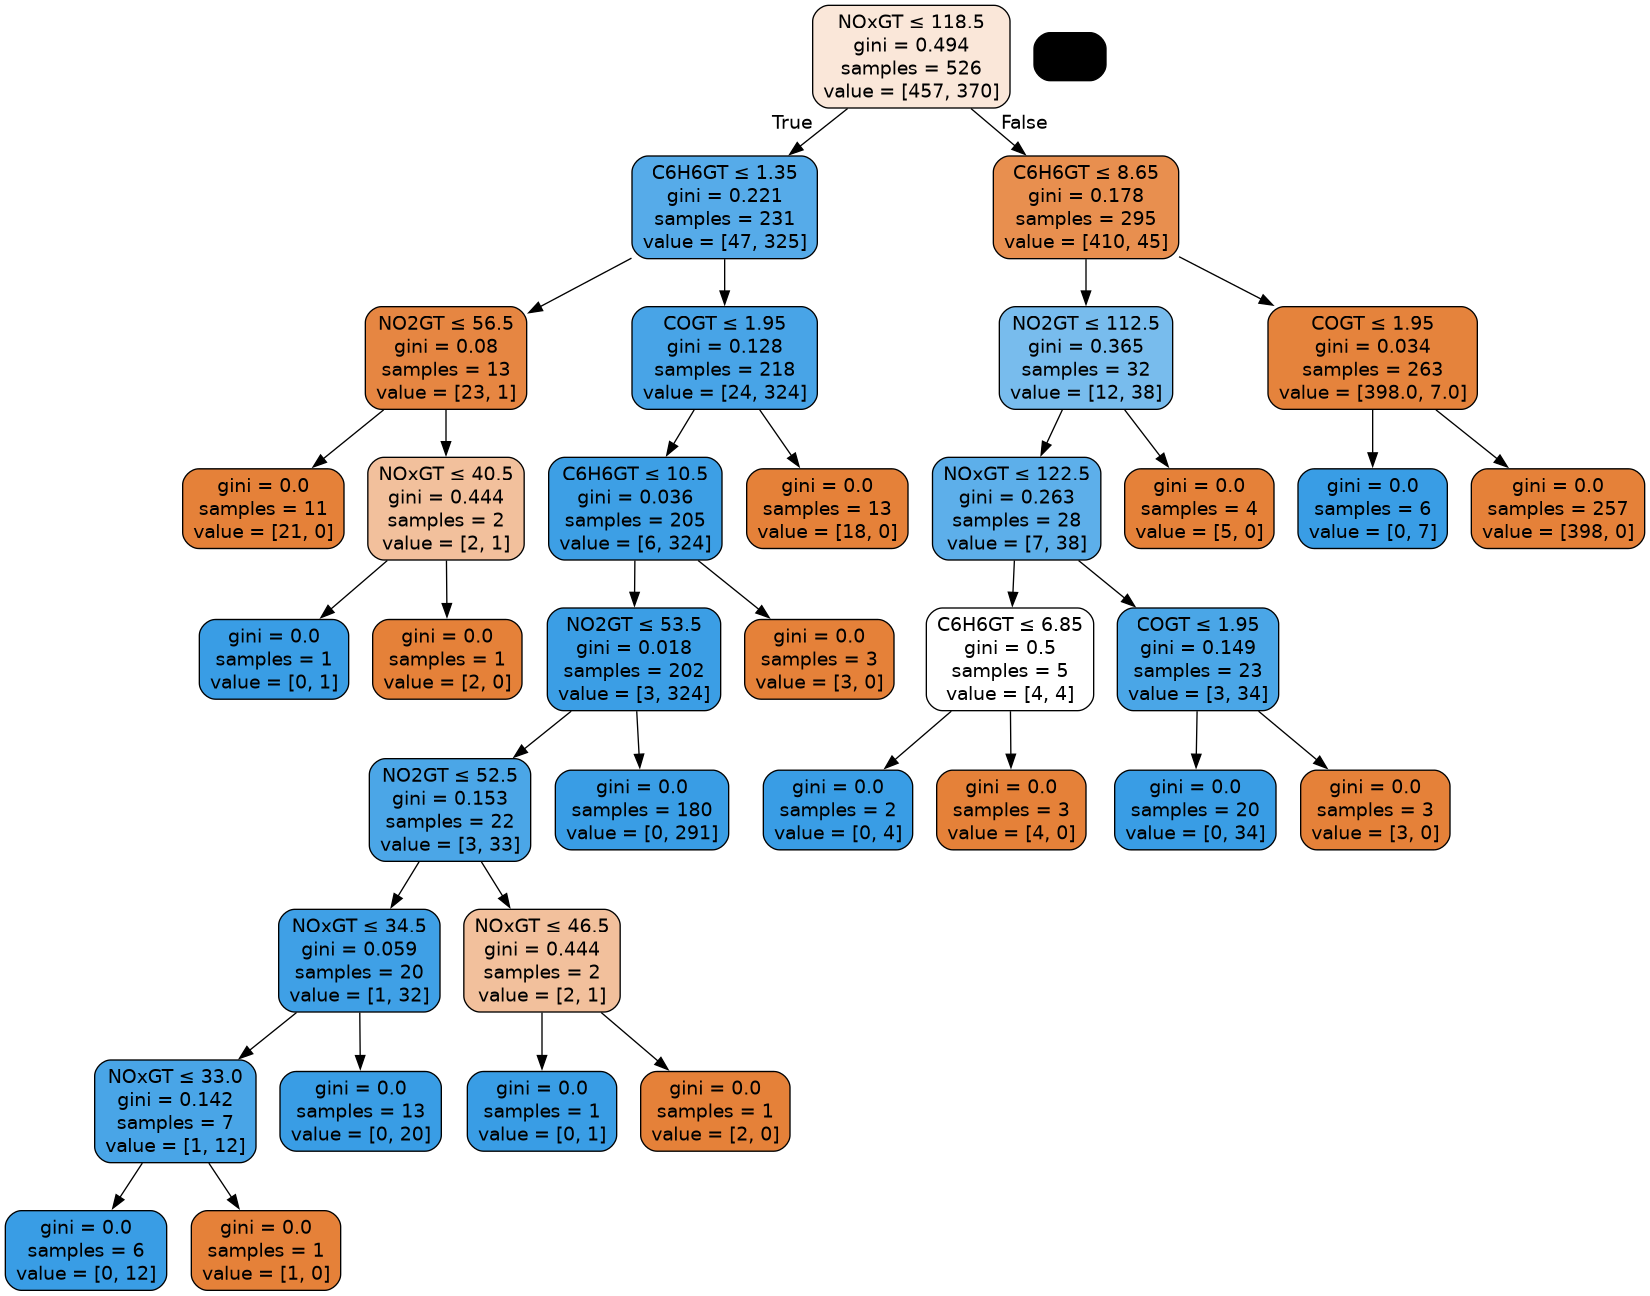

In [122]:
Image(get_png_tree(tree1.estimators_[3], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width="500")

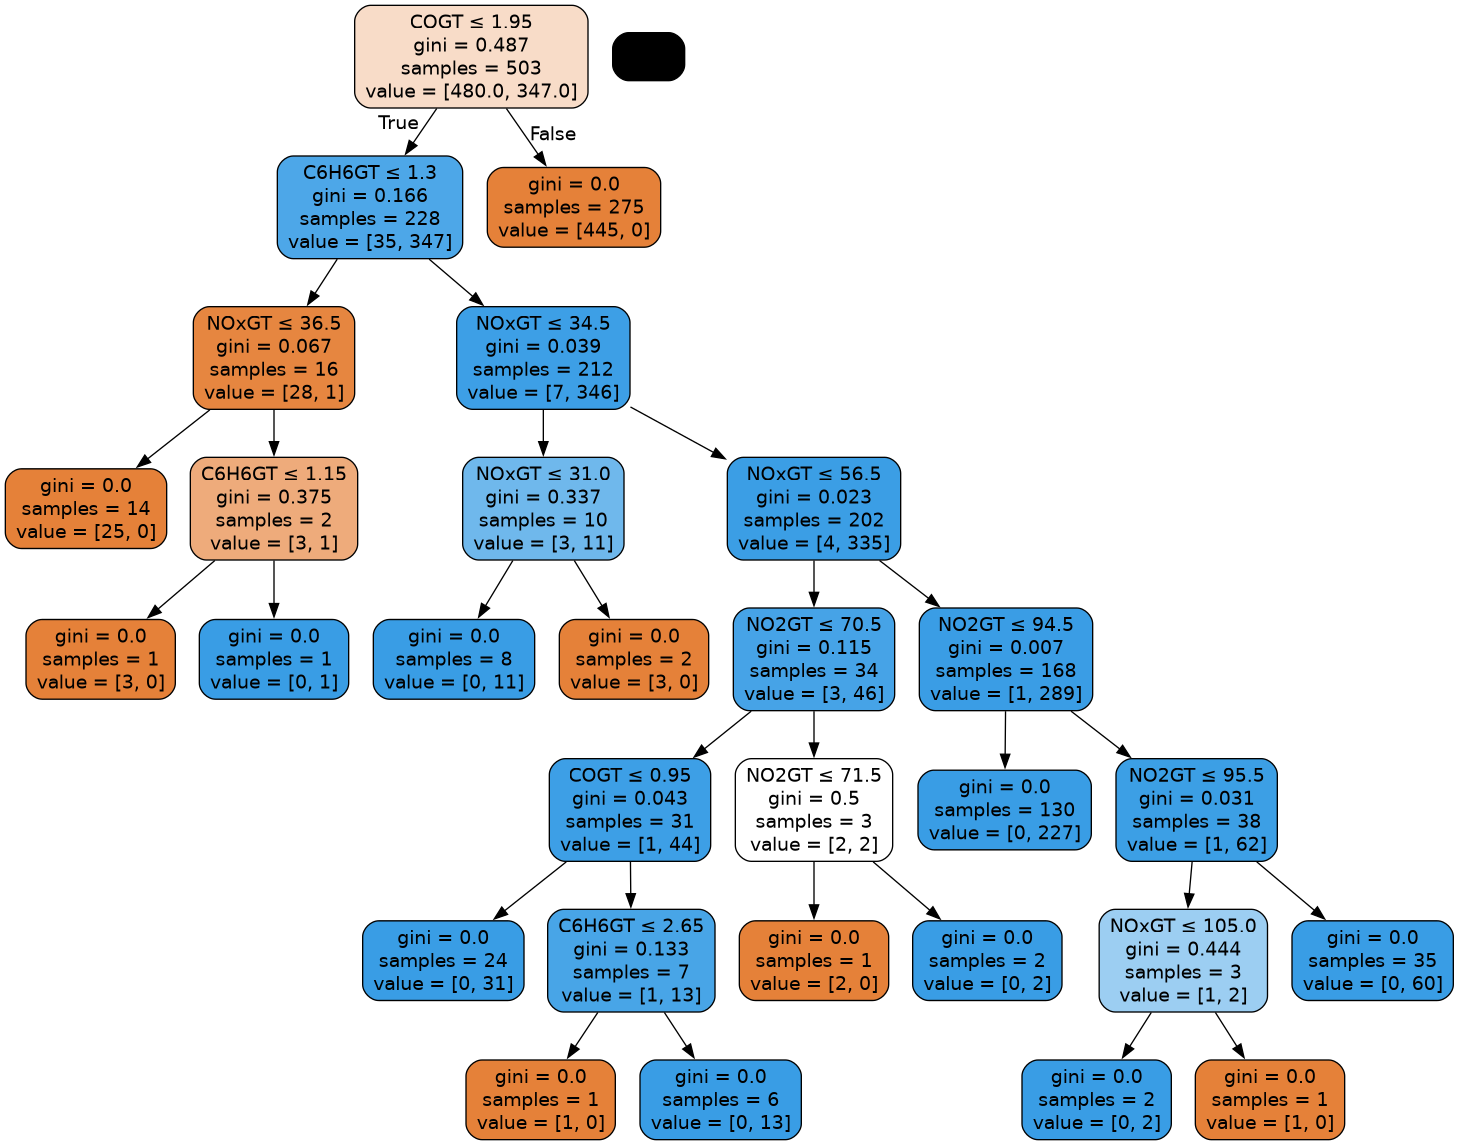

In [123]:
Image(get_png_tree(tree1.estimators_[4], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width="500")

## Визуализация результатов классификации

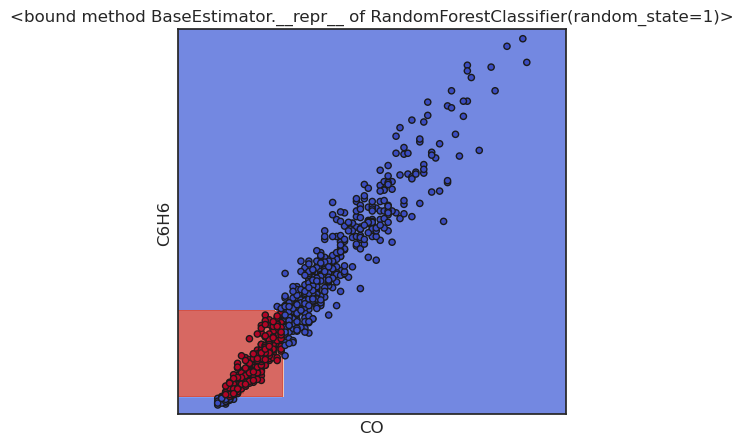

In [125]:
plot_cl(RandomForestClassifier(random_state=1))

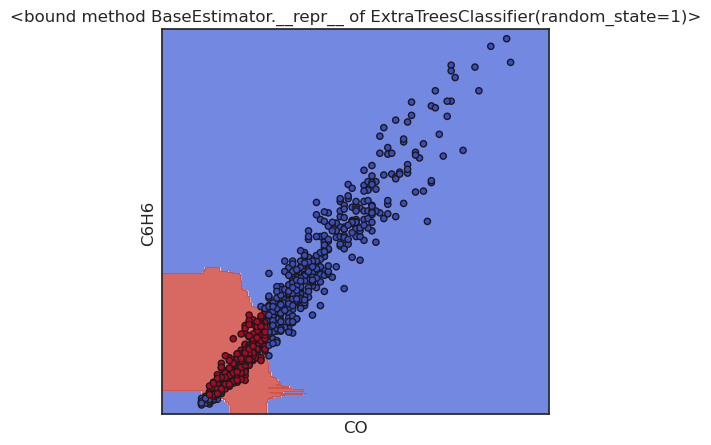

In [126]:
plot_cl(ExtraTreesClassifier(random_state=1))

## Важность признаков

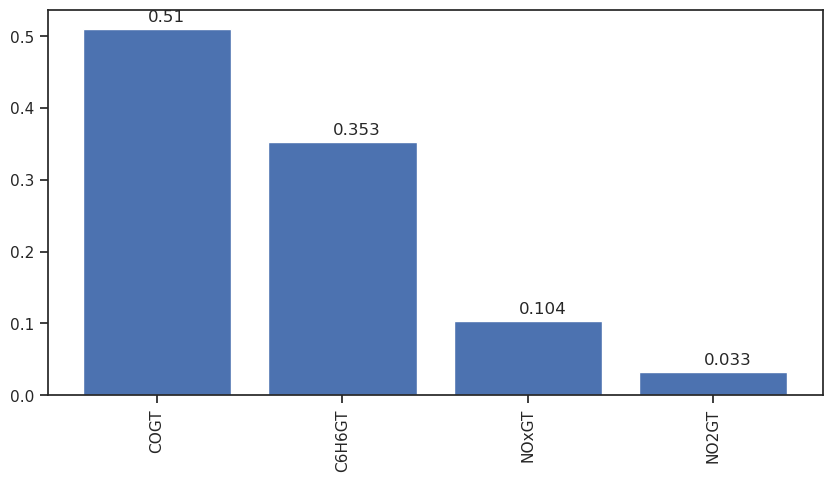

In [144]:
# Важность признаков
rf_cl = RandomForestClassifier(random_state=1)
rf_cl.fit(X, y)
_,_ = draw_feature_importances(rf_cl, X)

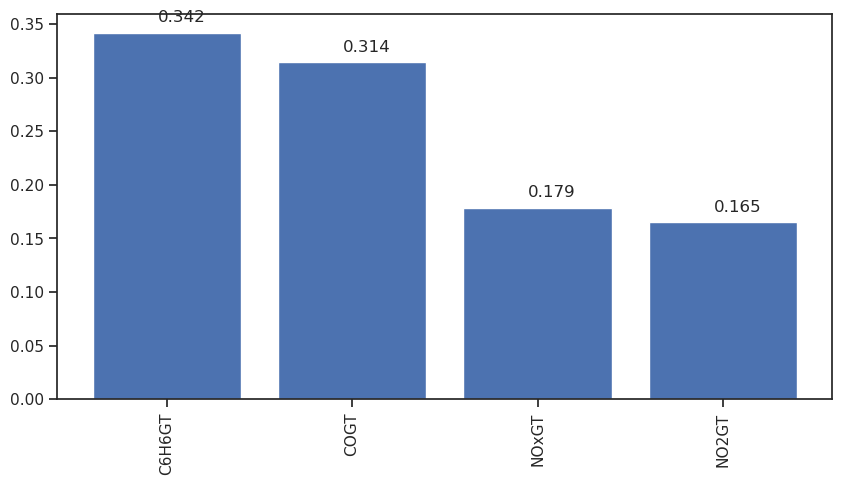

In [145]:
xtree_cl = ExtraTreesClassifier(random_state=1)
xtree_cl.fit(X, y)
_, _ = draw_feature_importances(xtree_cl, X)

# Алгоритм AdaBoost

In [127]:
# Обучим классификатор на 5 деревьях
ab1 = AdaBoostClassifier(n_estimators=5, algorithm='SAMME', random_state=10)
ab1.fit(X, y)

/home/maria/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


,estimator,None
,n_estimators,5
,learning_rate,1.0
,algorithm,'SAMME'
,random_state,10


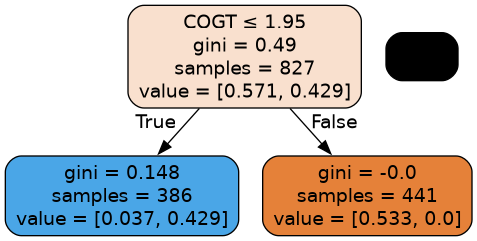

In [129]:
Image(get_png_tree(ab1.estimators_[0], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='40%')

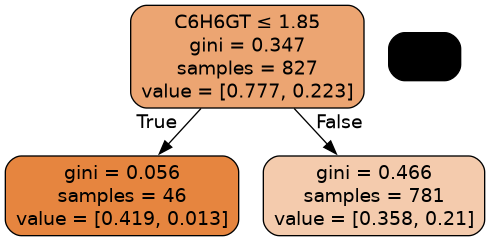

In [130]:
Image(get_png_tree(ab1.estimators_[1], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='40%')

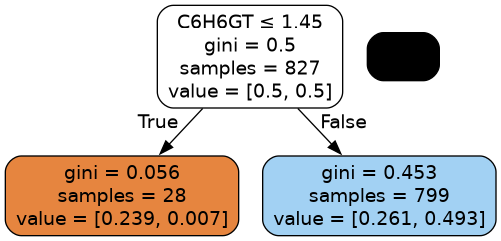

In [131]:
Image(get_png_tree(ab1.estimators_[2], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='40%')

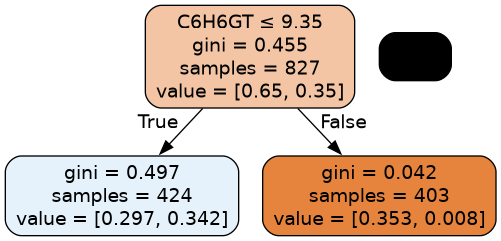

In [132]:
Image(get_png_tree(ab1.estimators_[3], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='40%')

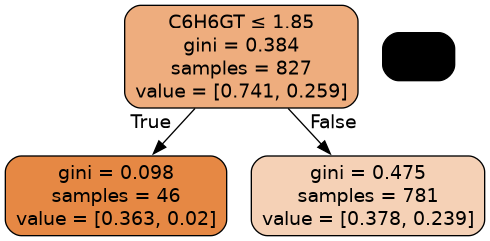

In [133]:
Image(get_png_tree(ab1.estimators_[4], ['COGT', 'C6H6GT', 'NOxGT', 'NO2GT']), width='40%')

In [134]:
ab1.estimator_weights_

array([3.24561198, 1.24832658, 1.00312547, 0.82626259, 1.05273402])

In [136]:
df1 = ab1.decision_function(X)
df1.shape

(827,)

In [137]:
df1[:10]

array([-1.45601018, -1.45601018, -1.0079322 , -1.0079322 ,  0.75214659,
        0.75214659,  0.75214659,  0.75214659,  0.75214659,  0.20815678])

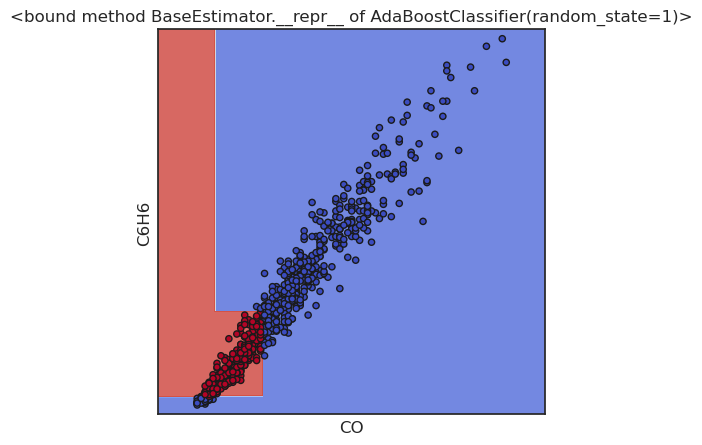

In [138]:
# Результаты классификации
plot_cl(AdaBoostClassifier(random_state=1))

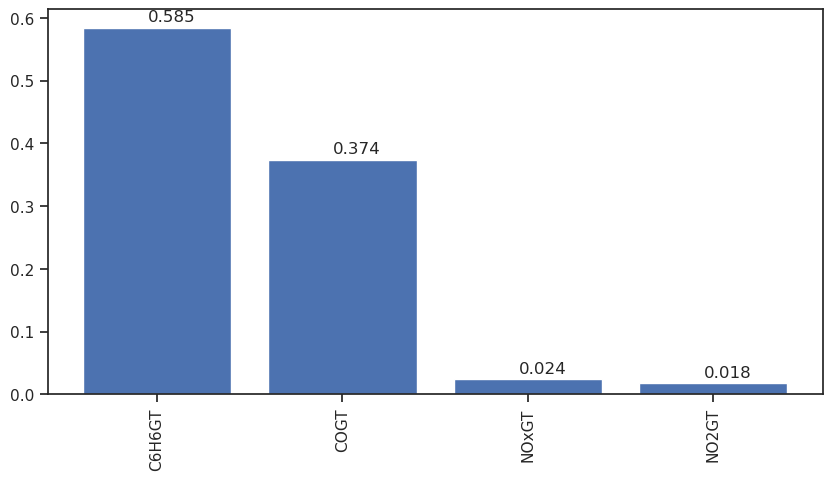

In [143]:
# Важность признаков
ab2 = AdaBoostClassifier(random_state=1)
ab2.fit(X, y)
_,_ = draw_feature_importances(ab2, X)

# Алгоритм градиентного бустинга

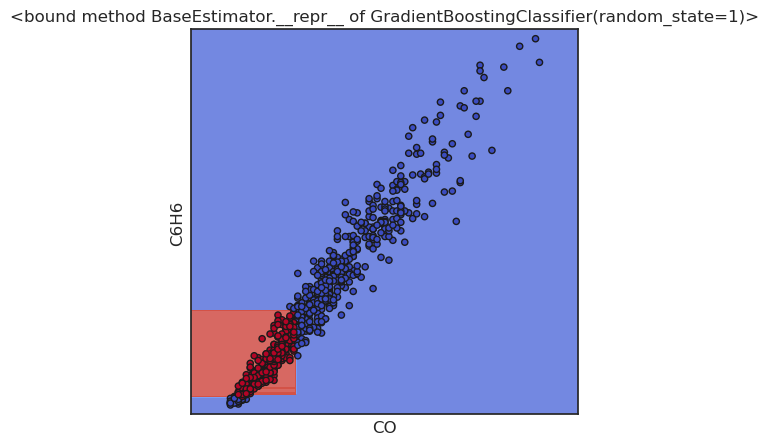

In [140]:
plot_cl(GradientBoostingClassifier(random_state=1))

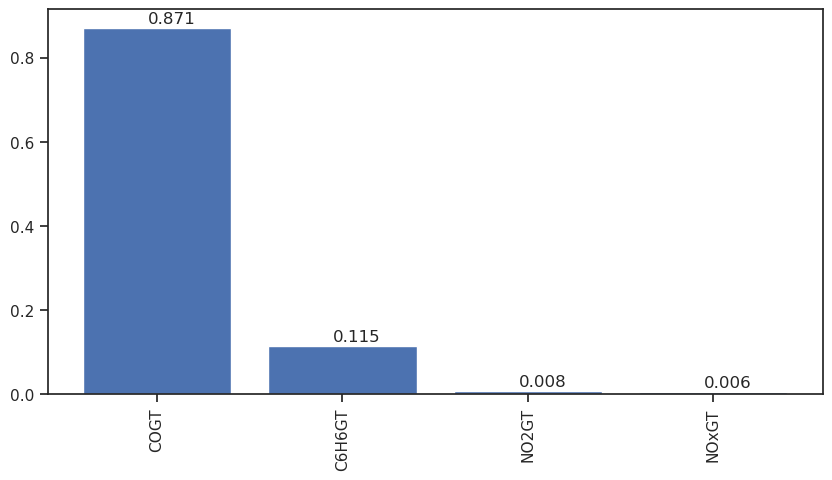

In [142]:
# Важность признаков
gb_cl = GradientBoostingClassifier(random_state=1)
gb_cl.fit(X, y)
_,_ = draw_feature_importances(gb_cl, X)